
<br>
<font face="Times New Roman">
<div dir=ltr align=center>
<font color=0F5298 size=7>
Digital Image Processing <br>
<font color=2565AE size=5>
Department Of Mathematical Sciences <br>
Spring 2025<br>
<font color=3C99D size=5>
Assignment 3 <br>
</div>


---



### Full Name : Amir Malekhosseini
### Student Number : 401100528
___

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

First, read the image:

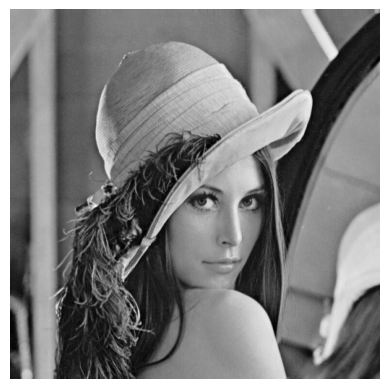

In [3]:
gray = cv2.imread("lena.png", 0)
plt.axis('off')
plt.imshow(gray, cmap="gray")

Complete the sp function below to add random salt and pepper noise to the image with rate n. generate noisy images with rates 0.1, 0.2, 0.3, ... ,1.

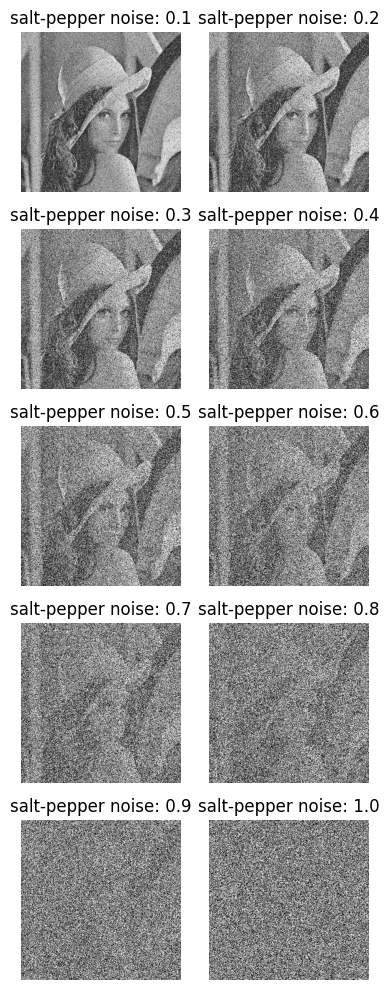

In [4]:
def sp(pic, n):
    noise_img = pic.copy()
    random_matrix = np.random.rand(*pic.shape)
    pepper = random_matrix < n/2
    salt = (random_matrix >= n/2) & (random_matrix < n)
    noise_img[pepper] = 0
    noise_img[salt] = 255
    return noise_img


a = []

for i in range(1, 11):

    a.append(sp(gray, 0.1 * i))


fig, axes = plt.subplots(5, 2, figsize=(4, 10))
axes = axes.flatten()


for idx, (ax, img) in enumerate(zip(axes, a)):

    ax.imshow(img, cmap='gray')

    ax.set_title(f"salt-pepper noise: {np.round((idx + 1) * 0.1, 2)}")

    ax.axis('off')


plt.tight_layout()

plt.show()

Implement a function that takes a noisy image as input and applies a mean filter of size kernel_size * kernel_size on it. Use numpy only.



In [5]:

def apply_mean_filter(image, kernel_size):
    pad = kernel_size // 2
    padded = np.pad(image, pad, mode='constant')
    filtered_image = np.zeros_like(image)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            window = padded[i:i+kernel_size, j:j+kernel_size]
            filtered_image[i, j] = np.mean(window)
    return filtered_image

In [6]:
def display_results(noisy_image, method_function, filter_name):
    pics = [noisy_image]
    titles = ["Original noisy image"]
    kernel_sizes = [3, 5, 7]
    for i, k in enumerate(kernel_sizes):
        filtered_image = method_function(a[0], k)
        pics.append(filtered_image)
        titles.append(f"{filter_name} filter with kernel size {k}")

    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    axes = axes.flatten()

    for idx, (ax, img) in enumerate(zip(axes, pics)):
        ax.imshow(img, cmap='gray')
        ax.set_title(titles[idx])
        ax.axis('off')

    plt.tight_layout()
    plt.show()


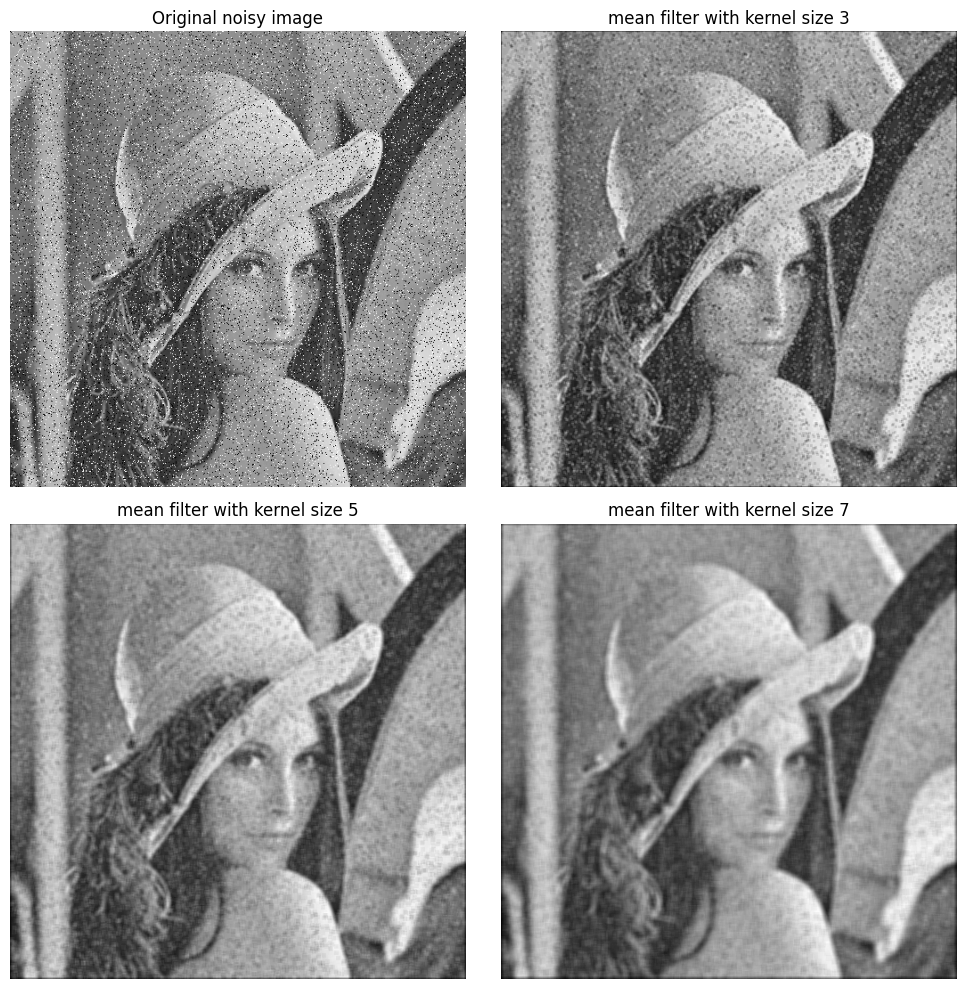

In [7]:
display_results(a[0], apply_mean_filter, filter_name="mean")

### Theory Question:
Explain the reason behind the differences between the outputs of a 3✕3, 5✕5, and 7✕7 mean filter.

### Your Answer:  
Larger kernels (e.g., 7x7) average more pixels, resulting in increased blurring and smoother images but loss of fine details compared to smaller kernels (e.g., 3x3).


Use cv2's built-in function(s) to do the same as the mean filter you implemented above.



In [8]:
def builtin_mean_filter(image, kernel_size):
    filtered_image = cv2.blur(image, (kernel_size, kernel_size))
    return filtered_image

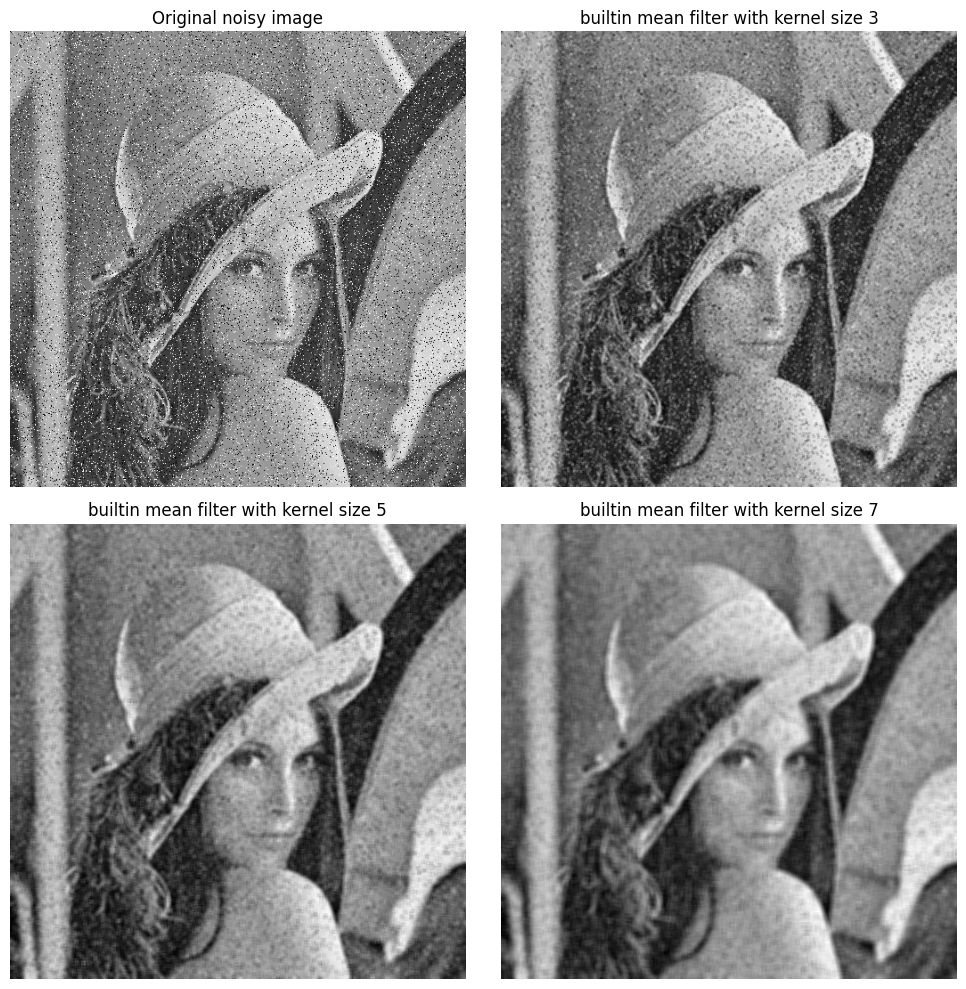

In [9]:
display_results(a[0], builtin_mean_filter, filter_name="builtin mean")

Implement a function that takes a noisy image as input and applies a median filter of size kernel_size * kernel_size on it. Use numpy only.

In [10]:
def apply_median_filter(image, kernel_size):
    pad = kernel_size // 2
    padded = np.pad(image, pad, mode='constant')
    filtered_image = np.zeros_like(image)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            window = padded[i:i+kernel_size, j:j+kernel_size]
            filtered_image[i, j] = np.median(window)
    return filtered_image

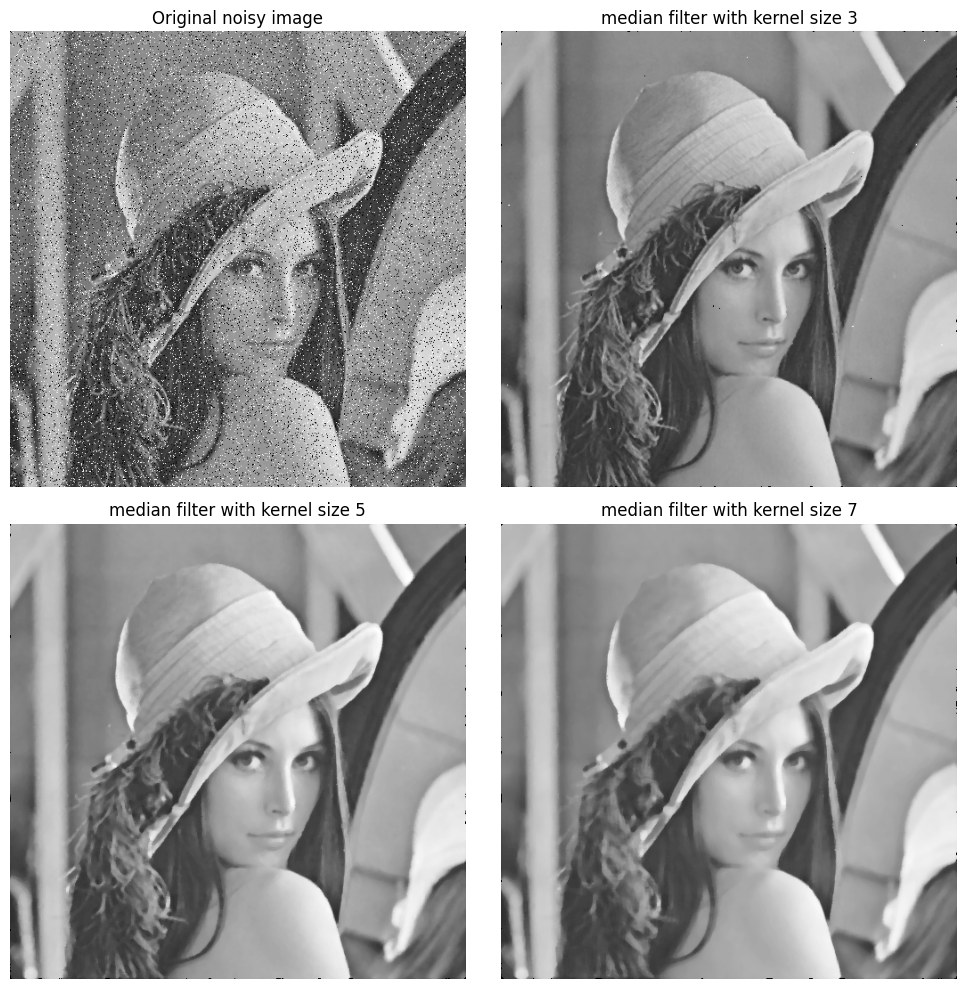

In [11]:
display_results(a[0], apply_median_filter, filter_name="median")

### Theory Question:
Explain the reason behind the differences between the outputs of a 3✕3, 5✕5, and 7✕7 median filter.

### Your Answer: 
Larger kernels can remove larger noise patches but may also smooth out smaller details. Edges are preserved better than with mean filters.


Use cv2's built-in function(s) to do the same as the median filter you implemented above.

In [12]:
def builtin_median_filter(image, kernel_size):
    filtered_image = cv2.medianBlur(image.astype(np.uint8), kernel_size)
    return filtered_image

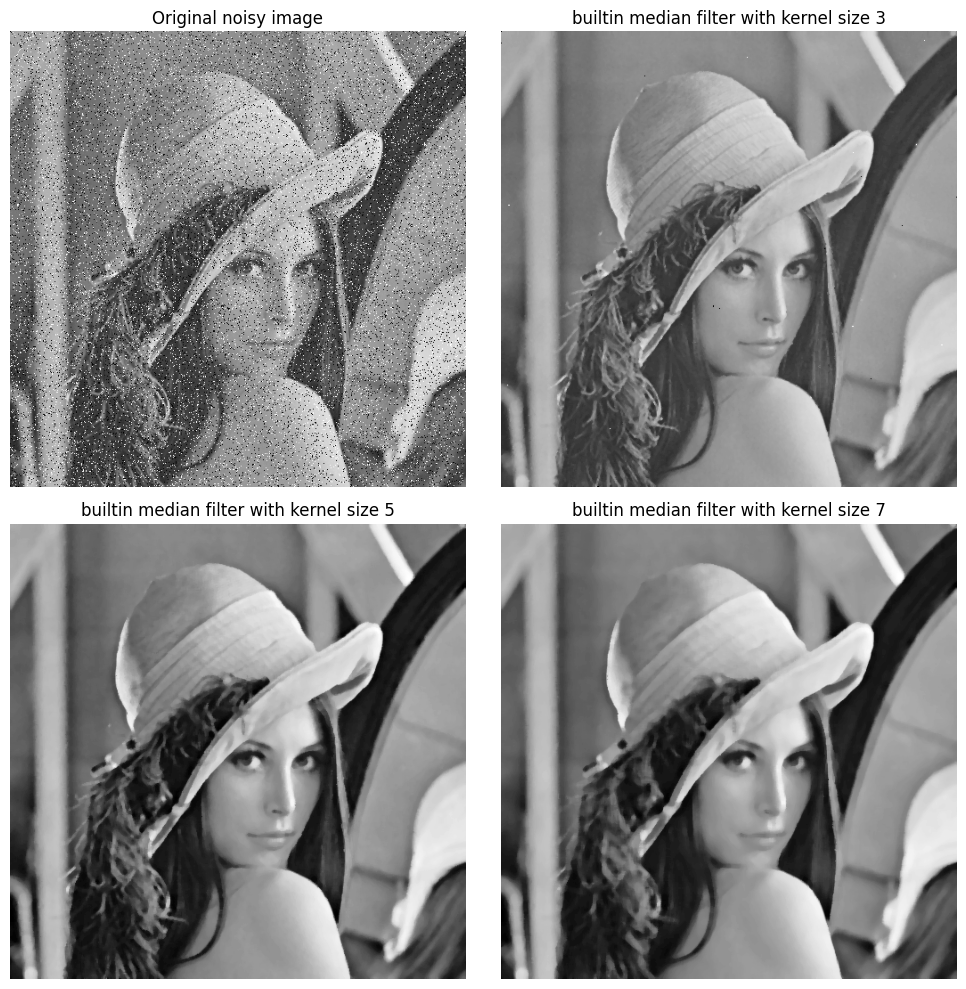

In [13]:
display_results(a[0], builtin_median_filter, filter_name="builtin median")

### Theory Question:
Explain the reason behind the differences between the outputs of a mean and median filter of the same size. Which one performs better on the task of removing salt and pepper noise? why?

### Your Answer: 
The median filter performs better on salt-and-pepper noise because it replaces the pixel with the median value, effectively ignoring extreme values (0 and 255). The mean filter averages noisy pixels, which does not fully remove the noise.